In [ ]:

!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install transformers datasets accelerate
!pip install scikit-learn pandas numpy tqdm spacy matplotlib seaborn
!pip install nlpaug  # for optional augmentation

# Download spaCy model
!python -m spacy download en_core_web_sm

Looking in indexes: https://download.pytorch.org/whl/cu121
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 13.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 146.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
!pip install -U bitsandbytes selecting the
'Restart kernel' or 'Restart runtime' option.

[ ]
!pip install -U bitsandbytes
Collecting bitsandbytes
  Downloading bitsandbytes-0.49.1-py3-none-manylinux_2_24_x86_64.whl.metadata (10 kB)
Requirement already satisfied: torch<3,>=2.3 in /usr/loc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 19.1 MB/s eta 0:00:00


In [ ]:
# ============================================================
# FULL HYBRID ABSA CODE (WITH FULL METRICS, GRAPHS, F2, etc.)
# ============================================================

# -------------------- AUTH --------------------
from huggingface_hub import login
login(token="")  # optional

# -------------------- IMPORTS --------------------
import os, re, random, gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModel,
    LlamaModel, BitsAndBytesConfig,
    get_cosine_schedule_with_warmup
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from torch.optim import AdamW
from tqdm.auto import tqdm

# -------------------- SEED & DEVICE --------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------- AMP-SAFE RMSNorm & SwiGLU --------------------
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(dim))
        self.eps = eps

    def forward(self, x):
        orig_dtype = x.dtype
        x = x.float()
        var = x.pow(2).mean(-1, keepdim=True)
        x = x * torch.rsqrt(var + self.eps)
        return (self.weight * x).to(orig_dtype)

class SwiGLU(nn.Module):
    def forward(self, x):
        x, gate = x.chunk(2, dim=-1)
        return F.silu(gate) * x

# -------------------- FOCAL LOSS --------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.5):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# -------------------- HYBRID MODEL (unchanged) --------------------
class ABSA_RoBERTa_LLaMA32(nn.Module):
    def __init__(self, num_labels=3, dropout=0.3, tau=0.8):
        super().__init__()
        self.encoder = AutoModel.from_pretrained("roberta-large")
        self.h = self.encoder.config.hidden_size

        bnb = BitsAndBytesConfig(load_in_8bit=True)
        self.llama = LlamaModel.from_pretrained(
            "meta-llama/Llama-3.2-3B",
            quantization_config=bnb,
            device_map="auto"
        )
        for p in self.llama.parameters():
            p.requires_grad = False

        self.llama_proj = nn.Linear(self.llama.config.hidden_size, self.h)
        self.llama_gate = nn.Parameter(torch.tensor(-4.0))

        self.cross_attn = nn.MultiheadAttention(self.h, 16, batch_first=True)
        self.self_attn = nn.MultiheadAttention(self.h, 16, batch_first=True)

        self.gate_mlp = nn.Sequential(
            nn.Linear(self.h * 3, self.h * 4),
            SwiGLU(),
            nn.Linear(self.h * 2, 3)
        )

        self.classifier = nn.Sequential(
            nn.Linear(self.h, self.h * 4),
            SwiGLU(),
            nn.Linear(self.h * 2, self.h),
            RMSNorm(self.h),
            nn.Dropout(dropout),
            nn.Linear(self.h, num_labels)
        )

        self.norm = RMSNorm(self.h)
        self.tau = tau

    def forward(self, input_ids, attention_mask, dep_distances, aspect_mask):
        seq = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        aspect_rep = (seq * aspect_mask.unsqueeze(-1)).sum(1) / aspect_mask.sum(1, keepdim=True).clamp(min=1e-9)

        cross_out, _ = self.cross_attn(aspect_rep.unsqueeze(1), seq, seq,
                                      key_padding_mask=~attention_mask.bool())
        cross_rep = cross_out.squeeze(1)

        refined, _ = self.self_attn(seq, seq, seq, key_padding_mask=~attention_mask.bool())

        dep_w = torch.exp(-dep_distances / self.tau) * attention_mask.float()
        local_rep = (refined * dep_w.unsqueeze(-1)).sum(1) / dep_w.sum(1, keepdim=True).clamp(min=1e-9)
        global_rep = refined.mean(1)

        gates = torch.sigmoid(self.gate_mlp(torch.cat([local_rep, global_rep, cross_rep], dim=-1)))

        fused = (gates[:, 0:1] * local_rep + gates[:, 1:2] * global_rep + gates[:, 2:3] * cross_rep)

        with torch.no_grad():
            llama_out = self.llama(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
            llama_rep = llama_out.mean(1)

        llama_rep = llama_rep.to(self.llama_proj.weight.dtype)
        llama_rep = self.llama_proj(llama_rep)

        fused = fused + torch.sigmoid(self.llama_gate) * llama_rep
        fused = self.norm(fused)

        return self.classifier(fused)

# -------------------- DATASET (unchanged) --------------------
class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len=192):
        self.df = df.reset_index(drop=True)
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self): return len(self.df)

    def __getitem__(self, i):
        r = self.df.iloc[i]
        enc = self.tok(
            r["sentence"], r["aspect"],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        ids = enc["input_ids"].squeeze(0)
        mask = enc["attention_mask"].squeeze(0)

        asp_ids = self.tok(r["aspect"], add_special_tokens=False)["input_ids"]
        aspect_mask = torch.zeros(self.max_len)
        for j in range(len(ids) - len(asp_ids) + 1):
            if ids[j:j+len(asp_ids)].tolist() == asp_ids:
                aspect_mask[j:j+len(asp_ids)] = 1
                break

        return {
            "input_ids": ids,
            "attention_mask": mask,
            "aspect_mask": aspect_mask,
            "dep_distances": torch.zeros(self.max_len),
            "label": torch.tensor(r["label"], dtype=torch.long)
        }

# -------------------- LOAD DATA --------------------
train = pd.read_csv("/content/restaurants_train_processed_final.csv")
test  = pd.read_csv("/content/Restaurent_test_dataset_shuffled.csv")

label_map = {"positive":0, "negative":1, "neutral":2}
train["label"] = train["polarity"].map(label_map)
test["label"] = test["polarity"].map(label_map)

train["sentence"] = train["Sentence"].str.lower()
train["aspect"]   = train["aspect_term"].str.lower()
test["sentence"]  = test["Sentence"].str.lower()
test["aspect"]    = test["aspect_term"].str.lower()

train_df, val_df = train_test_split(train, test_size=0.15, stratify=train["label"], random_state=42)

tokenizer = AutoTokenizer.from_pretrained("roberta-large")

train_loader = DataLoader(ABSADataset(train_df, tokenizer), batch_size=16, shuffle=True)
val_loader   = DataLoader(ABSADataset(val_df, tokenizer), batch_size=16)
test_loader  = DataLoader(ABSADataset(test, tokenizer), batch_size=16)

# -------------------- TRAINING SETUP --------------------
model = ABSA_RoBERTa_LLaMA32().to(device)

weights = compute_class_weight("balanced", classes=np.array([0,1,2]), y=train_df["label"])
criterion = FocalLoss(alpha=torch.tensor(weights).float().to(device))

optimizer = AdamW([
    {"params": model.encoder.parameters(), "lr": 5e-6},
    {"params": model.llama_proj.parameters(), "lr": 1e-5},
    {"params": [model.llama_gate], "lr": 5e-6},
    {"params": [p for n,p in model.named_parameters() if "encoder" not in n and "llama" not in n], "lr": 3e-5}
])

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=200,
    num_training_steps=len(train_loader) * 30
)

scaler = torch.cuda.amp.GradScaler()

# -------------------- TRACKING LISTS --------------------
val_f1_history = []
val_acc_history = []
best_f1 = 0.0

# -------------------- TRAIN LOOP WITH METRICS --------------------
for epoch in range(30):
    model.train()
    for b in tqdm(train_loader, desc=f"Epoch {epoch+1}/30 [Train]"):
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(
                b["input_ids"].to(device),
                b["attention_mask"].to(device),
                b["dep_distances"].to(device),
                b["aspect_mask"].to(device)
            )
            loss = criterion(logits, b["label"].to(device))

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

    # ---------------- Validation ----------------
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for b in val_loader:
            out = model(
                b["input_ids"].to(device),
                b["attention_mask"].to(device),
                b["dep_distances"].to(device),
                b["aspect_mask"].to(device)
            )
            preds.extend(out.argmax(1).cpu().numpy())
            trues.extend(b["label"].numpy())

    val_f1 = f1_score(trues, preds, average="macro")
    val_acc = accuracy_score(trues, preds)
    val_f1_history.append(val_f1)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch+1}/30 - Val Macro F1: {val_f1:.4f} | Val Accuracy: {val_acc:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_hybrid_absa.pt")
        print("  >>> New best model saved!")




Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

...

/tmp/ipython-input-2158974213.py:234: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 29/30 - Val Macro F1: 0.8456 | Val Accuracy: 0.8887


Epoch 30/30 [Train]:   0%|          | 0/188 [00:00<?, ?it/s]

/tmp/ipython-input-2158974213.py:234: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 30/30 - Val Macro F1: 0.8456 | Val Accuracy: 0.8887


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda
Model loaded successfully (OOM-safe)

FINAL TEST RESULTS
              precision    recall  f1-score   support

    positive     0.9264    0.9624    0.9441       719
    negative     0.8802    0.8802    0.8802       192
     neutral     0.7590    0.6495    0.7000       194

    accuracy                         0.8932      1105
   macro avg     0.8552    0.8307    0.8414      1105
weighted avg     0.8890    0.8932    0.8901      1105

Overall Accuracy : 0.8932
Macro F1-score   : 0.8414


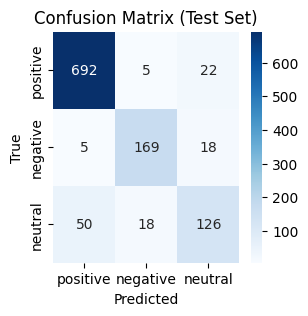


FINAL METRICS TABLE
    Class Precision  Recall F1-Score F2-Score Support
 positive    0.9264  0.9624   0.9441    0.955     719
 negative    0.8802  0.8802   0.8802   0.8802     192
  neutral     0.759  0.6495      0.7   0.6688     194
Macro Avg    0.8552  0.8307   0.8414        -       -
 Accuracy         -       -        -   0.8932    1105


In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_recall_fscore_support
)

# -------------------- CLEAN GPU --------------------
torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# -------------------- RECREATE MODEL (OOM-SAFE) --------------------
model = ABSA_RoBERTa_LLaMA32()


# Move non-LLaMA modules to GPU
model.encoder.to(device)
model.llama_proj.to(device)
model.classifier.to(device)
model.cross_attn.to(device)
model.self_attn.to(device)
model.gate_mlp.to(device)
model.norm.to(device)

# Move Parameter correctly
model.llama_gate.data = model.llama_gate.data.to(device)


# -------------------- LOAD CHECKPOINT (SKIP LLaMA) --------------------
ckpt = torch.load("best_hybrid_absa.pt", map_location="cpu")

filtered_ckpt = {
    k: v for k, v in ckpt.items()
    if not k.startswith("llama.")
}

model.load_state_dict(filtered_ckpt, strict=False)
model.eval()

print("Model loaded successfully (OOM-safe)")

# -------------------- TEST INFERENCE --------------------
test_preds, test_trues = [], []

with torch.no_grad():
    for b in test_loader:
        logits = model(
            b["input_ids"].to(device),
            b["attention_mask"].to(device),
            b["dep_distances"].to(device),
            b["aspect_mask"].to(device)
        )

        preds = logits.argmax(dim=1).cpu().numpy()
        test_preds.extend(preds)
        test_trues.extend(b["label"].numpy())

# -------------------- METRICS --------------------
class_names = ["positive", "negative", "neutral"]

precision, recall, f1, support = precision_recall_fscore_support(
    test_trues, test_preds, labels=[0,1,2], average=None
)

accuracy = accuracy_score(test_trues, test_preds)
macro_f1 = f1_score(test_trues, test_preds, average="macro")

def fbeta_score(p, r, beta=2):
    return (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-8)

f2_scores = [fbeta_score(p, r, beta=2) for p, r in zip(precision, recall)]

# -------------------- PRINT RESULTS --------------------
print("\n" + "="*65)
print("FINAL TEST RESULTS")
print("="*65)

print(classification_report(
    test_trues,
    test_preds,
    target_names=class_names,
    digits=4
))

print(f"Overall Accuracy : {accuracy:.4f}")
print(f"Macro F1-score   : {macro_f1:.4f}")

# -------------------- CONFUSION MATRIX --------------------
cm = confusion_matrix(test_trues, test_preds, labels=[0,1,2])

plt.figure(figsize=(3,3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# -------------------- FINAL METRICS TABLE --------------------
metrics_df = pd.DataFrame({
    "Class": class_names,
    "Precision": np.round(precision, 4),
    "Recall": np.round(recall, 4),
    "F1-Score": np.round(f1, 4),
    "F2-Score": np.round(f2_scores, 4),
    "Support": support
})

metrics_df.loc[len(metrics_df)] = [
    "Macro Avg",
    round(precision.mean(), 4),
    round(recall.mean(), 4),
    round(macro_f1, 4),
    "-",
    "-"
]

metrics_df.loc[len(metrics_df)] = [
    "Accuracy",
    "-",
    "-",
    "-",
    round(accuracy, 4),
    len(test_trues)
]

print("\nFINAL METRICS TABLE")
print(metrics_df.to_string(index=False))

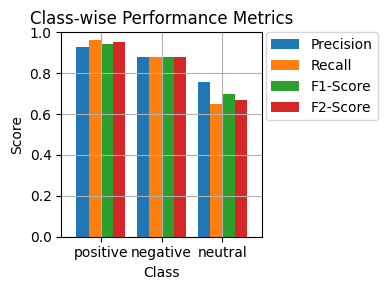

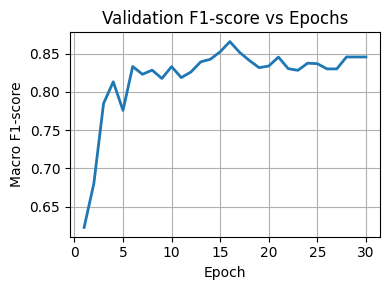

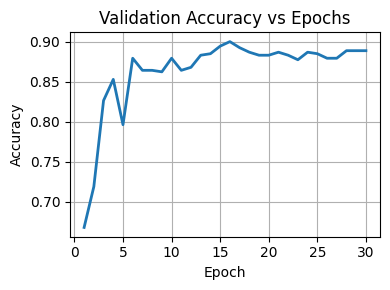

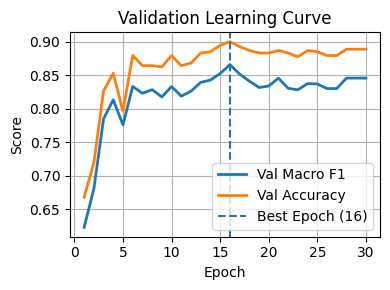

In [ ]:
# ============================================================
# FINAL METRICS & GRAPHS (CLEAN, NO OVERLAP, NO POINTS)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. BAR GRAPH — CLASS-WISE METRICS (LEGEND OUTSIDE)
# ============================================================

plot_df = metrics_df.iloc[:3].set_index("Class")[
    ["Precision", "Recall", "F1-Score", "F2-Score"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(4,3),
    ylim=(0,1),
    width=0.8,
    grid=True
)

ax.set_title("Class-wise Performance Metrics")
ax.set_ylabel("Score")
ax.set_xlabel("Class")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Move legend OUTSIDE (does not affect bars)
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0
)

plt.tight_layout()
plt.show()

# ============================================================
# 2. LINE GRAPH — VALIDATION MACRO F1 (CURVE ONLY)
# ============================================================

epochs = np.arange(1, len(val_f1_history) + 1)

plt.figure(figsize=(4,3))
plt.plot(epochs, val_f1_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Macro F1-score")
plt.title("Validation F1-score vs Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 3. LINE GRAPH — VALIDATION ACCURACY (CURVE ONLY)
# ============================================================

plt.figure(figsize=(4,3))
plt.plot(epochs, val_acc_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 4. COMBINED LEARNING CURVE (CURVES ONLY)
# ============================================================

best_epoch = np.argmax(val_f1_history) + 1

plt.figure(figsize=(4,3))
plt.plot(epochs, val_f1_history, label="Val Macro F1", linewidth=2)
plt.plot(epochs, val_acc_history, label="Val Accuracy", linewidth=2)

plt.axvline(
    best_epoch,
    linestyle="--",
    linewidth=1.5,
    label=f"Best Epoch ({best_epoch})"
)

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation Learning Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
